In [1]:
# DATA CLEANING 

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/netflix_titles.csv')

print("Dataset shape:",df.shape)
print("\nColumn Names:\n",df.columns.tolist())
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

Dataset shape: (8807, 12)

Column Names:
 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Missing Values Before Cleaning:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [2]:
# HANDLE MISSING VALUES

df['director'] = df['director'].fillna('Unknown') 
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df.dropna(subset=['date_added','rating','duration'],inplace=True)
df['date_added'] = df['date_added'].str.strip()
df['year_added'] = pd.to_datetime(df['date_added']).dt.year

print("Missing Values After Cleaning:")
print(df.isnull().sum())
print("\nDataset Shape After Cleaning:",df.shape)

Missing Values After Cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
dtype: int64

Dataset Shape After Cleaning: (8790, 13)


In [3]:
# DUPLICATE CHECK

duplicates = df.duplicated().sum()
print("Duplicated Rows:", duplicates)

title_duplicates = df.duplicated(subset=['title','type']).sum()
print("Duplicated Title:", title_duplicates)

print("Final Dataset Shape:", df.shape)

Duplicated Rows: 0
Duplicated Title: 0
Final Dataset Shape: (8790, 13)


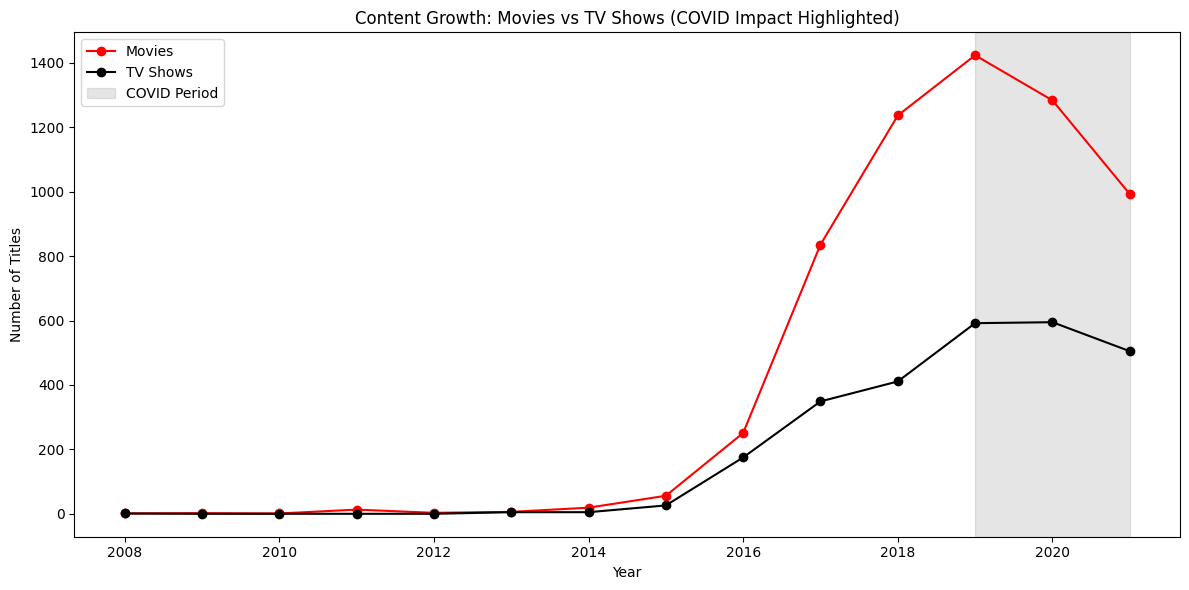

In [4]:
# CONTENT TRENDS OVER TIME 

# Movies vs TV Shows per year
trends = df.groupby(['year_added', 'type']).size().unstack().fillna(0)

plt.figure(figsize=(12, 6))
plt.plot(trends.index, trends['Movie'], marker='o', label='Movies', color='red')
plt.plot(trends.index, trends['TV Show'], marker='o', label='TV Shows', color='black')

# COVID impact
plt.axvspan(2019, 2021, color='gray', alpha=0.2, label='COVID Period')

plt.title('Content Growth: Movies vs TV Shows (COVID Impact Highlighted)')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend()
plt.tight_layout()
plt.show()

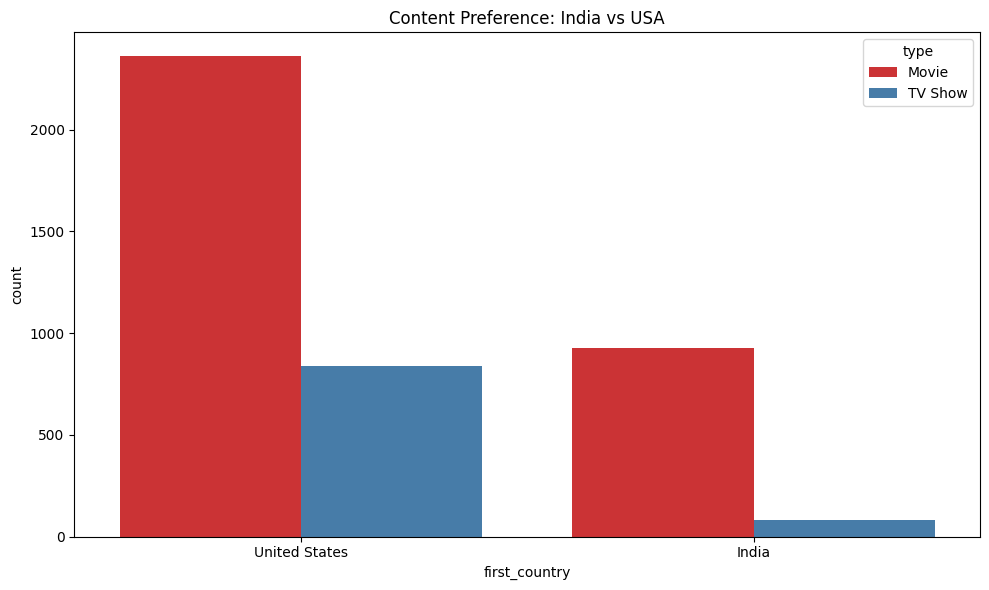

In [5]:
# REGIONAL ANALYSIS — INDIA vs USA

df['first_country'] = df['country'].str.split(',').str[0].str.strip()
comparison_df = df[df['first_country'].isin(['India', 'United States'])]

plt.figure(figsize=(10, 6))
sns.countplot(x='first_country', hue='type', data=comparison_df, palette='Set1')
plt.title('Content Preference: India vs USA')
plt.tight_layout()
plt.show()


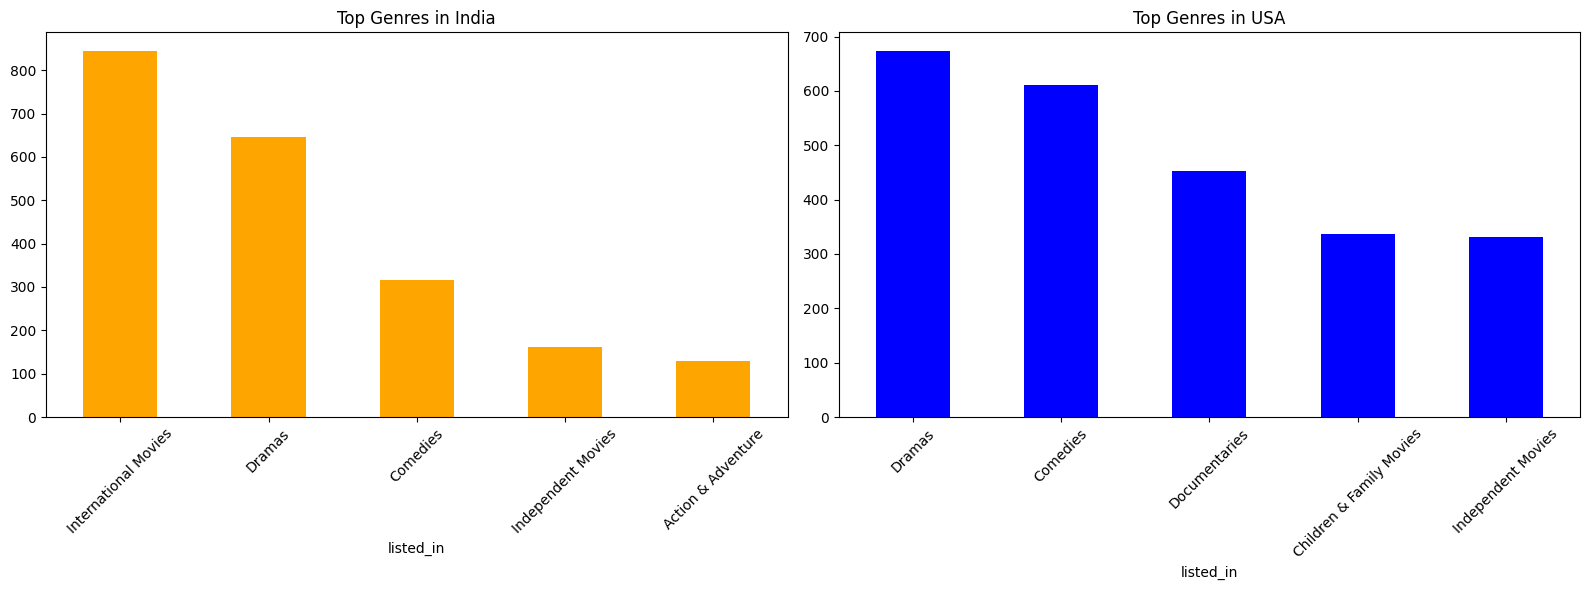

In [6]:
# GENRE DEEP DIVE

# India top 5 genres
india_genres = df[df['first_country'] == 'India']['listed_in'].str.split(', ').explode().value_counts().head(5)

# USA top 5 genres
usa_genres = df[df['first_country'] == 'United States']['listed_in'].str.split(', ').explode().value_counts().head(5)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

india_genres.plot(kind='bar', ax=ax[0], color='orange')
ax[0].set_title('Top Genres in India')

usa_genres.plot(kind='bar', ax=ax[1], color='blue')
ax[1].set_title('Top Genres in USA')

ax[0].tick_params(axis='x', rotation=45)
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# BUSINESS CONCLUSIONS & INSIGHTS

print("=" * 55)
print("       NETFLIX CONTENT ANALYSIS — KEY INSIGHTS")
print("=" * 55)

# Insight 1: Movies vs TV Shows ratio
total = len(df)
movies = len(df[df['type'] == 'Movie'])
tvshows = len(df[df['type'] == 'TV Show'])
movie_pct = round((movies / total) * 100, 1)
tv_pct = round((tvshows / total) * 100, 1)

print(f"\n INSIGHT 1: Content Library Composition")
print(f"  Movies  : {movies} titles ({movie_pct}%)")
print(f"  TV Shows: {tvshows} titles ({tv_pct}%)")
print(f"  → Netflix is primarily a Movie platform,")
print(f"    but TV Show share is steadily growing.")

# Insight 2: COVID Impact
trends = df.groupby(['year_added', 'type']).size().unstack().fillna(0)
pre_covid_avg = trends.loc[2017:2019].mean().mean()
covid_avg = trends.loc[2020:2021].mean().mean()
drop_pct = round(((pre_covid_avg - covid_avg) / pre_covid_avg) * 100, 1)

print(f"\n INSIGHT 2: COVID-19 Impact on Content Addition")
print(f"  Avg titles/year (2017-2019): {round(pre_covid_avg)}")
print(f"  Avg titles/year (2020-2021): {round(covid_avg)}")
print(f"  Drop: ~{drop_pct}% decrease during pandemic.")
print(f"  → Production halts caused a clear dip in")
print(f"    new content added during COVID years.")

# Insight 3: India vs USA
india_count = len(df[df['first_country'] == 'India'])
usa_count = len(df[df['first_country'] == 'United States'])

india_movie_pct = round(len(df[(df['first_country']=='India') & (df['type']=='Movie')]) / india_count * 100, 1)
usa_movie_pct = round(len(df[(df['first_country']=='United States') & (df['type']=='Movie')]) / usa_count * 100, 1)

print(f"\n INSIGHT 3: Regional Content Strategy")
print(f"  India  — Total: {india_count} | Movies: {india_movie_pct}%")
print(f"  USA    — Total: {usa_count} | Movies: {usa_movie_pct}%")
print(f"  → India heavily favors Movies over TV Shows.")
print(f"    USA has a more balanced content mix.")

# Insight 4: Top Genre
top_genre = df['listed_in'].str.split(', ').explode().value_counts().index[0]
top_genre_count = df['listed_in'].str.split(', ').explode().value_counts().iloc[0]

print(f"\n INSIGHT 4: Most Popular Genre")
print(f"  '{top_genre}' leads with {top_genre_count} titles.")
print(f"  → Netflix should continue investing in")
print(f"    '{top_genre}' as it dominates the library.")

print("\n" + "=" * 55)
print("  Analysis Complete!")
print("=" * 55)

       NETFLIX CONTENT ANALYSIS — KEY INSIGHTS

 INSIGHT 1: Content Library Composition
  Movies  : 6126 titles (69.7%)
  TV Shows: 2664 titles (30.3%)
  → Netflix is primarily a Movie platform,
    but TV Show share is steadily growing.

 INSIGHT 2: COVID-19 Impact on Content Addition
  Avg titles/year (2017-2019): 808
  Avg titles/year (2020-2021): 844
  Drop: ~-4.5% decrease during pandemic.
  → Production halts caused a clear dip in
    new content added during COVID years.

 INSIGHT 3: Regional Content Strategy
  India  — Total: 1008 | Movies: 92.0%
  USA    — Total: 3202 | Movies: 73.7%
  → India heavily favors Movies over TV Shows.
    USA has a more balanced content mix.

 INSIGHT 4: Most Popular Genre
  'International Movies' leads with 2752 titles.
  → Netflix should continue investing in
    'International Movies' as it dominates the library.

  Analysis Complete!
